In [ ]:
import h5py
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from neuralop.models import FNO

(1000, 16384, 2)


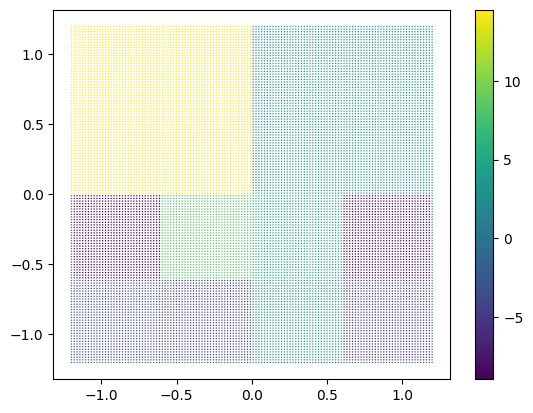

In [2]:
datapath = Path("/home/spol/repos/hypermagnetics/data")
db = h5py.File(datapath / "val_res32_large_m_41_1000_10_fno_128.h5", "r")
res = 128
batch = 200
res_out = 128 //4
lim = 1.2
idx = 15

# Check fno function
print(db["input"].shape)
grids = np.meshgrid(
            np.linspace(-lim, lim, res),
            np.linspace(-lim, lim, res),
            np.linspace(0, 0, 1),
        )
grid = np.concatenate([g.ravel()[:, None] for g in grids], axis=-1)
x_grid = np.array(grid[:, 0].reshape((res, res)))
y_grid = np.array(grid[:, 1].reshape((res, res)))

# Plot example
contour = plt.scatter(x_grid, y_grid, c=db["input"][idx,...,0].reshape((res, res)), cmap='viridis', s=1, edgecolors='none')
plt.colorbar(contour)

In [3]:
modelpath = Path("/home/spol/repos/hypermagnetics/models/fno")
modelname = "fno_large_m_128_1M"
model = FNO.from_checkpoint(save_folder=modelpath, save_name=modelname)

input = torch.from_numpy((
    np.array(db["input"][:batch])
    .reshape(batch, res, res, -1)
    .transpose(0, 3, 1, 2)).astype(np.float32)
)
out = model(input).to("cpu").detach().numpy()
print(out.shape)

(200, 1, 32, 32)


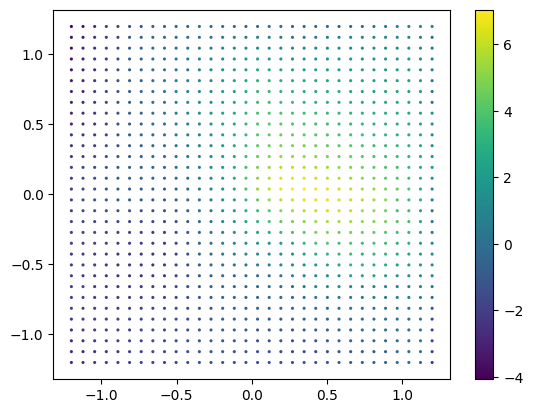

In [4]:
grids_out = np.meshgrid(
            np.linspace(-lim, lim, res_out),
            np.linspace(-lim, lim, res_out),
            np.linspace(0, 0, 1),
        )
grid_out = np.concatenate([g.ravel()[:, None] for g in grids_out], axis=-1)
x_grid_out = np.array(grid_out[:, 0].reshape((res_out, res_out)))
y_grid_out = np.array(grid_out[:, 1].reshape((res_out, res_out)))
contour = plt.scatter(x_grid_out, y_grid_out, c=out[idx, 0], cmap='viridis', s=5, edgecolors='none')
plt.colorbar(contour)

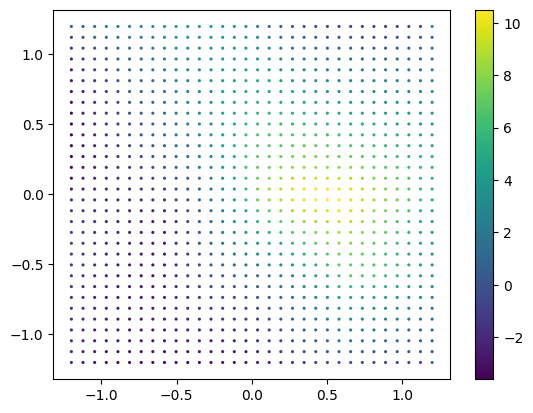

In [5]:
contour = plt.scatter(x_grid_out, y_grid_out, c=db["output"][idx].reshape((res_out, res_out)), cmap='viridis', s=5, edgecolors='none')
plt.colorbar(contour)

Median relative error: 0.6361056566238403
(200, 32, 32)


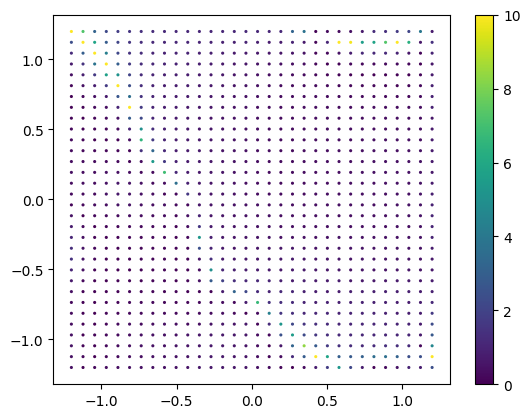

In [8]:
# Error calculation
error = np.abs(out[:, 0] - db["output"][:batch].reshape((batch, res_out, res_out)))
rel_error = error / np.abs(db["output"][:batch].reshape((batch, res_out, res_out)) + 1e-8)

mean_error = np.median(rel_error)
print(f"Median relative error: {mean_error}")
print(rel_error.shape)

norm = mcolors.Normalize(vmin=0, vmax=10)
contour = plt.scatter(x_grid_out, y_grid_out, c=rel_error[idx], cmap='viridis', s=5, edgecolors='none', norm=norm)
plt.colorbar(contour)

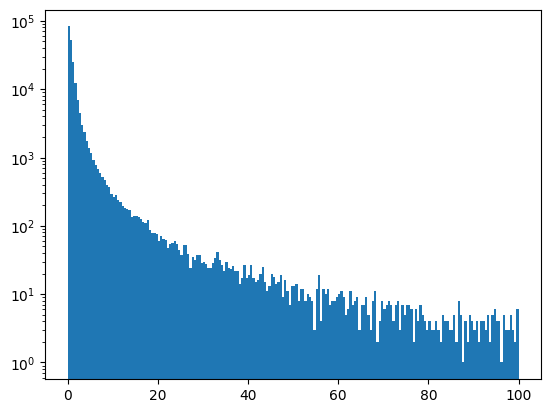

In [7]:
plt.hist(rel_error.flatten(), bins=200, range=(0, 100))
plt.yscale("log")